## Foundations of adaptive peer routing dynamics

The router role functions as a localized epistemic engine. Rather than relying on static capabilities, it continuously tracks the hidden cognitive and physical states of its neighboring LM worker peers using a discrete-time Kalman filter.

For each peer $i$, the router maintains a belief over a hidden state vector $\mathbf{x}_{k}^{(i)}$, representing the true physical latency and functional error rate at time step $k$:

$$
\mathbf{x}_k = \begin{bmatrix} l_k \\ \eta_k \end{bmatrix} \quad \text{(latency, error rate)}
$$

Because hardware and network conditions drift naturally over time, the state evolves according to a linear stochastic difference equation governed by process noise $\mathbf{w}_k \sim \mathcal{N}(0, \mathbf{Q})$:

$$
\mathbf{x}_k = \mathbf{x}_{k-1} + \mathbf{w}_{k-1}
$$

When the router dispatches a task to a peer, it receives a programmatic verification payload as a noisy measurement $\mathbf{z}_k$. The measurement is corrupted by observation noise $\mathbf{v}_k \sim \mathcal{N}(0, \mathbf{R})$:

$$
\mathbf{z}_k = \mathbf{x}_k + \mathbf{v}_k
$$

### Router belief update equations

Upon receiving a response (or a timeout), the router updates its belief state ($\hat{\mathbf{x}}$) and covariance matrix ($\mathbf{P}$) using the standard Kalman equations.

**1. Predict (A priori state estimate):**
$$
\hat{\mathbf{x}}_{k|k-1} = \hat{\mathbf{x}}_{k-1|k-1}
$$
$$
\mathbf{P}_{k|k-1} = \mathbf{P}_{k-1|k-1} + \mathbf{Q}
$$

**2. Update (A posteriori state estimate):**
The router calculates the Kalman gain $\mathbf{K}_k$, balancing its current uncertainty against the variance of the incoming measurement:
$$
\mathbf{K}_k = \mathbf{P}_{k|k-1} (\mathbf{P}_{k|k-1} + \mathbf{R})^{-1}
$$
$$
\hat{\mathbf{x}}_{k|k} = \hat{\mathbf{x}}_{k|k-1} + \mathbf{K}_k (\mathbf{z}_k - \hat{\mathbf{x}}_{k|k-1})
$$
$$
\mathbf{P}_{k|k} = (\mathbf{I} - \mathbf{K}_k) \mathbf{P}_{k|k-1}
$$

### The routing cost function

To balance exploiting historically reliable nodes with exploring potentially recovered nodes, the router minimizes a cost function $J$ penalized by the trace of the covariance matrix (representing epistemic uncertainty):

$$
J^{(i)} = \hat{l}^{(i)} + \lambda \hat{\eta}^{(i)} - \beta \sqrt{\text{Tr}(\mathbf{P}^{(i)})}
$$

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


########################### SYSTEM DEFINITIONS ############################

# Mathematical parameters for the Kalman Filter
# We increase Q to prevent the filter from 'going to sleep', allowing it to adapt to sudden changes.
Q = np.array([[0.05, 0.0],    # Process noise for latency drift
              [0.0, 0.02]])   # Process noise for error rate drift

R = np.array([[0.2, 0.0],     # Measurement noise (network jitter)
              [0.0, 0.15]])   # Measurement noise (stochastic hallucination variance)

def kalman_update(x_hat, P, z, Q, R):
    # Predict
    P_pred = P + Q

    # Update
    S = P_pred + R
    K = P_pred @ np.linalg.inv(S)

    x_hat_new = x_hat + K @ (z - x_hat)
    P_new = (np.eye(2) - K) @ P_pred

    # Mathematical bounding for valid physical ranges
    x_hat_new[0, 0] = max(0.01, x_hat_new[0, 0])  # Latency > 0
    x_hat_new[1, 0] = np.clip(x_hat_new[1, 0], 0.0, 1.0) # Error rate [0, 1]

    return x_hat_new, P_new

class WorkerPeer:
    def __init__(self, name, base_latency, base_error, node_type):
        self.name = name
        self.base_latency = base_latency
        self.base_error = base_error
        self.node_type = node_type
        self.current_latency = base_latency
        self.current_error = base_error

    def execute_task(self):
        # Local volatility
        latency_noise = np.random.normal(0, 0.1) if self.node_type == 'heavy' else np.random.normal(0, 0.3)
        actual_latency = max(0.1, self.current_latency + latency_noise)

        # Binary failure generation based on true underlying error probability
        actual_error = float(np.random.binomial(1, self.current_error))

        return np.array([[actual_latency], [actual_error]])

    def trigger_environmental_shock(self, new_latency, new_error):
        """Simulates 'hardware' throttling or context saturation in the network."""
        self.current_latency = new_latency
        self.current_error = new_error

In [ ]:

################ SIMULATION EXECUTION ##############################

NUM_STEPS = 150
BETA = 1.5   # Exploration coefficient
LAMBDA = 8.0 # Penalty multiplier for errors

workers = {
    "W1 (Heavy)": WorkerPeer("W1 (Heavy)", base_latency=1.2, base_error=0.05, node_type='heavy'),
    "W2 (Heavy)": WorkerPeer("W2 (Heavy)", base_latency=1.8, base_error=0.10, node_type='heavy'),
    "W3 (Edge)":  WorkerPeer("W3 (Edge)", base_latency=0.3, base_error=0.40, node_type='edge'),
    "W4 (Edge)":  WorkerPeer("W4 (Edge)", base_latency=0.5, base_error=0.30, node_type='edge')
}

# Initial belief states with high uncertainty
beliefs = {w: (np.array([[1.0], [0.5]]), np.eye(2) * 5.0) for w in workers.keys()}

# Data tracking
history = {w: {'tasks': 0, 'error_est': [], 'error_var': [], 'true_error': []} for w in workers.keys()}
traffic_log = []

for step in range(NUM_STEPS):
    # --- ENVIRONMENT SHOCK ---
    # At step 75, our best node (W1) suffers severe context saturation
    if step == 75:
        workers["W1 (Heavy)"].trigger_environmental_shock(new_latency=4.0, new_error=0.85)
        # W4 (Edge) gets optimized and becomes highly reliable
        workers["W4 (Edge)"].trigger_environmental_shock(new_latency=0.4, new_error=0.05)

    best_cost = float('inf')
    selected_worker = None

    for w_name, (x_hat, P) in beliefs.items():
        lat_est, err_est = x_hat[0, 0], x_hat[1, 0]
        uncertainty = np.sqrt(np.trace(P))

        cost = lat_est + (LAMBDA * err_est) - (BETA * uncertainty)
        if cost < best_cost:
            best_cost = cost
            selected_worker = w_name

    # Execution and Kalman update
    z_measurement = workers[selected_worker].execute_task()
    old_x, old_P = beliefs[selected_worker]
    new_x, new_P = kalman_update(old_x, old_P, z_measurement, Q, R)
    beliefs[selected_worker] = (new_x, new_P)

    # Logging
    workers[selected_worker].current_latency += np.random.normal(0, 0.02) # continuous minor drift
    history[selected_worker]['tasks'] += 1
    traffic_log.append(selected_worker)

    for w_name, (x_hat, P) in beliefs.items():
        history[w_name]['error_est'].append(x_hat[1, 0])
        history[w_name]['error_var'].append(P[1, 1])
        history[w_name]['true_error'].append(workers[w_name].current_error)

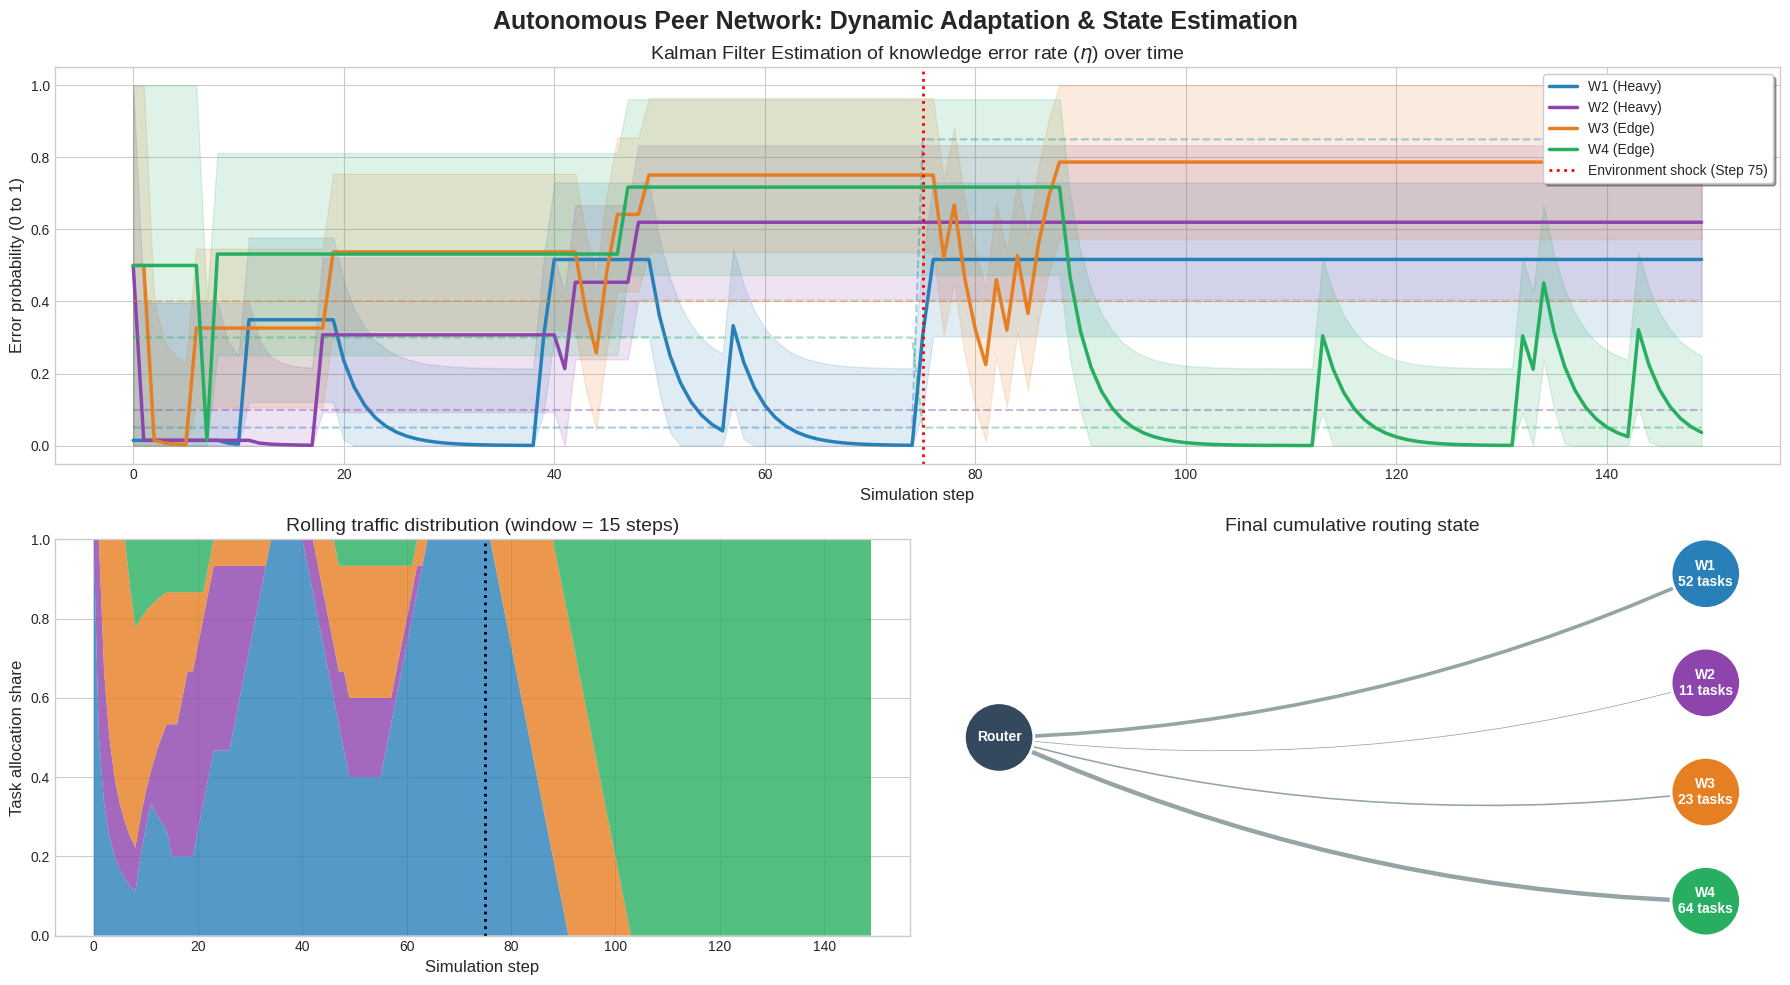

In [ ]:

########################## VISUALIZATION ##############################

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(18, 10))
fig.suptitle('Autonomous Peer Network: Dynamic Adaptation & State Estimation', fontsize=18, fontweight='bold', y=0.98)

colors = {'W1 (Heavy)': '#2980b9', 'W2 (Heavy)': '#8e44ad', 'W3 (Edge)': '#e67e22', 'W4 (Edge)': '#27ae60'}

# ---------------------------------------------------------
# Plot 1: Estimated Error Rate with Confidence Intervals
# ---------------------------------------------------------
ax1 = plt.subplot(2, 2, (1, 2))
ax1.set_title("Kalman Filter Estimation of knowledge error rate ($\eta$) over time", fontsize=14)

steps = np.arange(NUM_STEPS)
for w in workers.keys():
    est = np.array(history[w]['error_est'])
    var = np.array(history[w]['error_var'])
    std = np.sqrt(var)

    # Plot true state as dashed line
    ax1.plot(steps, history[w]['true_error'], color=colors[w], linestyle='--', alpha=0.4, linewidth=1.5)
    # Plot belief state
    ax1.plot(steps, est, color=colors[w], label=w, linewidth=2.5)
    # Fill confidence intervals (+/- 1 standard deviation)
    ax1.fill_between(steps, np.clip(est - std, 0, 1), np.clip(est + std, 0, 1), color=colors[w], alpha=0.15)

ax1.axvline(x=75, color='red', linestyle=':', linewidth=2, label='Environment shock (Step 75)')
ax1.set_ylabel("Error probability (0 to 1)", fontsize=12)
ax1.set_xlabel("Simulation step", fontsize=12)
ax1.set_ylim(-0.05, 1.05)
ax1.legend(loc='upper right', frameon=True, shadow=True)

# ---------------------------------------------------------
# Plot 2: Rolling Task Allocation (Adaptation Proof)
# ---------------------------------------------------------
ax2 = plt.subplot(2, 2, 3)
ax2.set_title("Rolling traffic distribution (window = 15 steps)", fontsize=14)

# Calculate rolling shares
df_traffic = pd.DataFrame({'worker': traffic_log})
df_dummies = pd.get_dummies(df_traffic['worker'])
# Ensure all workers are present in dummies even if 0
for w in workers.keys():
    if w not in df_dummies.columns:
        df_dummies[w] = 0
df_dummies = df_dummies[list(workers.keys())]

rolling_shares = df_dummies.rolling(window=15, min_periods=1).mean()

ax2.stackplot(steps, [rolling_shares[w] for w in workers.keys()],
              labels=workers.keys(), colors=[colors[w] for w in workers.keys()], alpha=0.8)
ax2.axvline(x=75, color='black', linestyle=':', linewidth=2)
ax2.set_ylabel("Task allocation share", fontsize=12)
ax2.set_xlabel("Simulation step", fontsize=12)
ax2.set_ylim(0, 1)

# ---------------------------------------------------------
# Plot 3: Network Topology Layout
# ---------------------------------------------------------
ax3 = plt.subplot(2, 2, 4)
ax3.set_title("Final cumulative routing state", fontsize=14)
ax3.axis('off')

G = nx.DiGraph()
G.add_node("Router", pos=(0, 0.5))
for i, w in enumerate(workers.keys()):
    y_pos = 0.8 - (i * 0.2)
    G.add_node(w, pos=(1, y_pos))
    G.add_edge("Router", w, weight=history[w]['tasks'])

pos = nx.get_node_attributes(G, 'pos')
node_colors = ['#34495e'] + [colors[w] for w in workers.keys()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2500, ax=ax3, edgecolors='white', linewidths=2)

# Draw edges with scaled thickness
edges = G.edges()
weights = [G[u][v]['weight'] * 0.05 for u, v in edges]
nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, edge_color='#95a5a6',
                       arrowsize=15, connectionstyle='arc3,rad=0.1', ax=ax3)

# Add clear labels with task counts
labels = {"Router": "Router"}
for w in workers.keys():
    labels[w] = f"{w.split(' ')[0]}\n{history[w]['tasks']} tasks"
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color='white', font_weight='bold', ax=ax3)

plt.tight_layout()
plt.show()